# Parte 1: Análise Exploratória

## Panorama dos Chamados

**Objetivo**: Explorar o corpus de 5.000 chamados da Central 1746 para entender as características e padrões dos dados. A análise foca no **problema de classificação**, de forma a encontrar possíveis insights que possam ajudar durante o processo de modelagem do problema.

## Setup

In [21]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DADOS_PATH = Path('../dados/chamados_com_predicoes.csv')
FIGURES_PATH = Path('../results/figures')

## Análise Inicial dos Dados

In [9]:
df = pd.read_csv(DADOS_PATH, encoding='utf-8')

In [10]:
df.head()

,id_chamado,data_abertura,bairro,canal,texto,categoria_real,pred_modelo_a,conf_modelo_a,pred_modelo_b,conf_modelo_b
0,2026003525,2026-01-16,Botafogo,app_1746,Festas com som automotivo ocorrem toda madruga...,barulho_perturbacao,barulho_perturbacao,0.939,barulho_perturbacao,0.883
1,2026001235,2026-06-20,Ilha do Governador,telefone_1746,Festas com som automotivo ocorrem toda madruga...,barulho_perturbacao,barulho_perturbacao,0.927,barulho_perturbacao,0.975
2,2026003000,2026-02-17,Campo Grande,portal_web,Solicito reparo urgente na iluminação pública ...,iluminacao_publica,iluminacao_publica,0.947,iluminacao_publica,0.829
3,2026002594,2026-01-15,Tijuca,app_1746,A luminária do poste da Rua Dias da Cruz esqui...,iluminacao_publica,coleta_lixo,0.964,iluminacao_publica,0.882
4,2026003670,2026-01-07,Penha,app_1746,Solicito remoção de entulho e lixo acumulado n...,coleta_lixo,buraco_via,0.924,coleta_lixo,0.765


In [6]:
print(df.shape)
print(df.dtypes)
print(df.isna().sum())

(5000, 10)
id_chamado          int64
data_abertura      object
bairro             object
canal              object
texto              object
categoria_real     object
pred_modelo_a      object
conf_modelo_a     float64
pred_modelo_b      object
conf_modelo_b     float64
dtype: object
id_chamado        0
data_abertura     0
bairro            0
canal             0
texto             0
categoria_real    0
pred_modelo_a     0
conf_modelo_a     0
pred_modelo_b     0
conf_modelo_b     0
dtype: int64


In [7]:
ids_duplicados = df['id_chamado'].duplicated().sum()
print(f'IDs duplicados: {ids_duplicados}')

IDs duplicados: 0


In [8]:
resumo_base = {
    'total_chamados': len(df),
    'periodo_inicio': df['data_abertura'].min(),
    'periodo_fim': df['data_abertura'].max(),
    'n_categorias': df['categoria_real'].nunique(),
    'n_bairros': df['bairro'].nunique(),
    'n_canais': df['canal'].nunique()
}

resumo_base

{'total_chamados': 5000,
 'periodo_inicio': '2026-01-01',
 'periodo_fim': '2026-06-30',
 'n_categorias': 8,
 'n_bairros': 15,
 'n_canais': 3}

## Análise Exploratória

In [15]:
cat_map = {
    'iluminacao_publica': 'Iluminação Pública',
    'buraco_via': 'Buraco em Via',
    'coleta_lixo': 'Coleta de Lixo',
    'esgoto_vazamento': 'Vazamento de Esgoto',
    'poda_arvore': 'Poda de Árvore',
    'estacionamento_irregular': 'Estacionamento Irregular',
    'barulho_perturbacao': 'Barulho / Perturbação',
    'sinalizacao': 'Sinalização'
}

cat_palette = {
    'iluminacao_publica': '#f4a261',
    'buraco_via': '#e76f51',
    'coleta_lixo': '#2a9d8f',
    'esgoto_vazamento': '#264653',
    'poda_arvore': '#8ab17d',
    'estacionamento_irregular': '#6b4c3b',
    'barulho_perturbacao': '#e9c46a',
    'sinalizacao': '#7b9ebf'
}

### 1. Distribuição das Categorias

In [13]:
cat_counts = df['categoria_real'].value_counts()
cat_props = df['categoria_real'].value_counts(normalize=True)

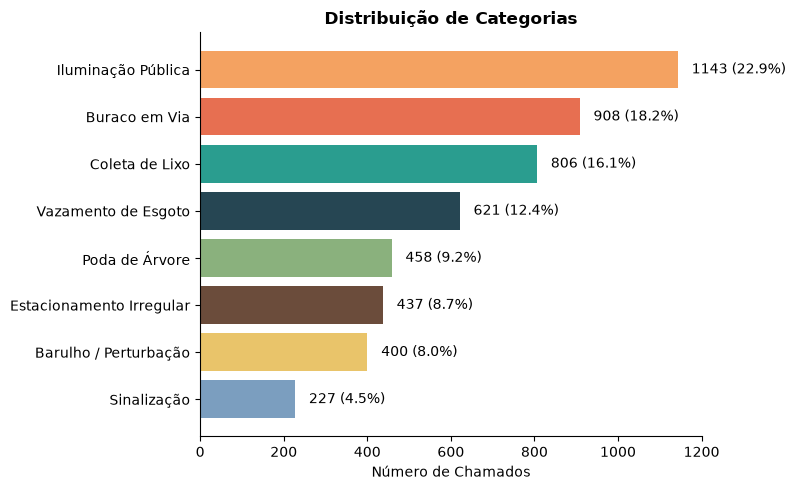

In [32]:
total = cat_counts.sum()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(
    [cat_map.get(c, c) for c in cat_counts.index],
    cat_counts.values,
    color=[cat_palette.get(c, '#888') for c in cat_counts.index]
)

labels = [
    f'{v} ({v/total:.1%})'
    for v in cat_counts.values
]

ax.bar_label(bars, labels=labels, padding=10)

ax.set_xlabel('Número de Chamados')
ax.set_title('Distribuição de Categorias', fontweight='bold')
ax.invert_yaxis()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'categoria_distribuicao.png', dpi=150)
plt.show()